# NSL-KDD — modeling walkthrough (step by step)

This notebook runs the whole modelling pipeline **interactively**, so you can see
every output and read what each step does and why. It reuses the exact same code
as the command-line scripts (`src/preprocess.py`, `src/evaluate.py`,
`src/train_mlp.py`) — nothing here is a toy reimplementation.

Flow: **load → preprocess → Random Forest → LightGBM → the rare-class problem →
MLP with/without class weighting → final comparison.**

> Tip: run cells top-to-bottom (Shift+Enter). Total runtime ~1–2 minutes.

In [1]:
# --- setup ---------------------------------------------------------------
# Set thread/OpenMP env BEFORE importing numpy/lightgbm/torch: LightGBM and
# PyTorch each bring their own OpenMP runtime, and mixing them multi-threaded in
# one Jupyter kernel can crash it. Single-threaded + KMP_DUPLICATE_LIB_OK is the
# stable combination for a walkthrough (the CLI scripts run fully parallel).
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")

import sys, warnings
from pathlib import Path
_here = Path.cwd()
ROOT = _here if (_here / "src").is_dir() else _here.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, seaborn as sns
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from lightgbm import LGBMClassifier

import data as D, preprocess as P, evaluate as E, train_mlp as T

# evaluate.py sets the headless 'Agg' backend on import (good for the scripts);
# the %matplotlib inline magic restores inline rendering AND wires up IPython's
# display hook so plt.show() emits figures into the notebook.
get_ipython().run_line_magic("matplotlib", "inline")
warnings.filterwarnings("ignore")            # keep the notebook output clean
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
RESULTS = {}                                  # we'll collect scores here
print("ready — modules loaded from", ROOT / "src")

ready — modules loaded from /Users/guneyaliunal/Desktop/don't delete/dazed&confused/nsl-kdd-ids/src


## Step 1 — Load the data

`data.load_nsl_kdd` reads the official split and adds two derived label columns:
`binary_label` (0=normal, 1=attack) and `attack_family` (normal/DoS/Probe/R2L/U2R).
We **do not** re-split randomly — the official `KDDTest+` deliberately contains
attack types unseen in training.

In [2]:
train = D.load_nsl_kdd("train")
test  = D.load_nsl_kdd("test")
print("train:", train.shape, " test:", test.shape)
display(train[["duration","protocol_type","service","flag","src_bytes",
               "label","attack_family","binary_label"]].head())
print("\nattack families in train:")
print(train["attack_family"].value_counts().reindex(D.FAMILY_ORDER))

train: (125973, 45)  test: (22544, 45)


,duration,protocol_type,service,flag,src_bytes,label,attack_family,binary_label
0,0,tcp,ftp_data,SF,491,normal,normal,0
1,0,udp,other,SF,146,normal,normal,0
2,0,tcp,private,S0,0,neptune,DoS,1
3,0,tcp,http,SF,232,normal,normal,0
4,0,tcp,http,SF,199,normal,normal,0



attack families in train:
attack_family
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


Notice the imbalance already: **U2R has ~52 rows, R2L ~995**, versus tens of
thousands of normal/DoS. Keep an eye on those two — they're the dangerous,
data-starved classes.

## Step 2 — Preprocess (one-hot + scale, leakage-safe)

`preprocess.prepare_nsl_kdd` fits a `ColumnTransformer` **on train only** and
applies it to both splits. Text columns (`protocol_type`, `service`, `flag`) are
one-hot encoded; numeric columns are standardized. 41 raw features become 122.

In [3]:
prep_bin   = P.prepare_nsl_kdd("binary")
prep_multi = P.prepare_nsl_kdd("multiclass")
print("binary   X_train:", prep_bin.X_train.shape, " X_test:", prep_bin.X_test.shape)
print("multiclass classes:", prep_multi.classes)
print("features after one-hot:", prep_bin.n_features, "(from 41 raw)")

binary   X_train: (125973, 122)  X_test: (22544, 122)
multiclass classes: ['normal', 'DoS', 'Probe', 'R2L', 'U2R']
features after one-hot: 122 (from 41 raw)


In [4]:
# See the one-hot expansion concretely for a single connection.
row0 = train.iloc[0]
print("raw categoricals of row 0 -> protocol_type=%r service=%r flag=%r"
      % (row0.protocol_type, row0.service, row0.flag))
names = prep_bin.feature_names
active = [names[i] for i in np.where(prep_bin.X_train[0] == 1.0)[0]
          if names[i].split('_')[0] in ("protocol", "service", "flag")]
print("one-hot columns that are 1 for row 0:", active)

raw categoricals of row 0 -> protocol_type='tcp' service='ftp_data' flag='SF'
one-hot columns that are 1 for row 0: ['protocol_type_tcp', 'service_ftp_data', 'flag_SF']


So the text value `service='ftp_data'` becomes a `service_ftp_data = 1` column
(and every other `service_*` = 0). No fake ordering is imposed — that's why we
one-hot instead of numbering the categories.

In [5]:
# A small helper to show confusion matrices inline (counts + recall).
def show_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(1, 2, figsize=(5 + 1.1*len(classes), 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax[0])
    ax[0].set(title="counts", xlabel="predicted", ylabel="true")
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax[1])
    ax[1].set(title="recall (row-normalized)", xlabel="predicted", ylabel="true")
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()
print("helper defined")

helper defined


## Step 3 — Random Forest (binary: normal vs attack)

A forest of decision trees voting together. We use sensible fixed parameters here
(the CLI script `train_baselines.py` does the light CV search); the goal in this
notebook is to *see* the behaviour.

accuracy   0.7776
macro-F1   0.7768
ROC-AUC    0.9620   PR-AUC 0.9644
attack recall 0.6295  (we catch this fraction of real attacks)


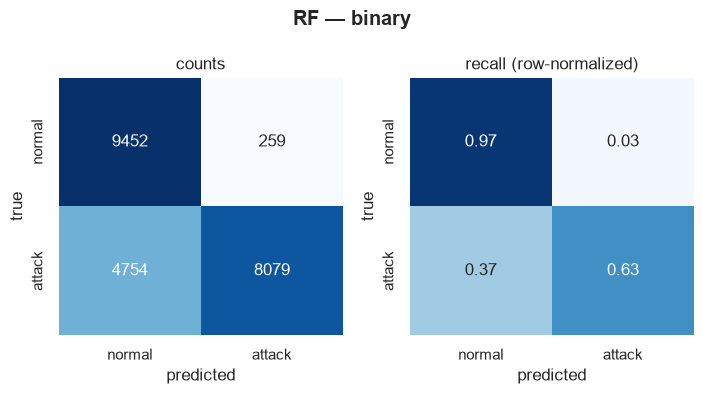

In [6]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)
rf.fit(prep_bin.X_train, prep_bin.y_train)
y_pred = rf.predict(prep_bin.X_test)
y_score = rf.predict_proba(prep_bin.X_test)[:, 1]
m = E.compute_metrics(prep_bin.y_test, y_pred, prep_bin.classes, y_score=y_score)
RESULTS["RF · binary"] = m
print(f"accuracy   {m['accuracy']:.4f}")
print(f"macro-F1   {m['macro_f1']:.4f}")
print(f"ROC-AUC    {m['roc_auc']:.4f}   PR-AUC {m['pr_auc']:.4f}")
print(f"attack recall {m['per_class']['attack']['recall']:.4f}  "
      f"(we catch this fraction of real attacks)")
show_confusion(prep_bin.y_test, y_pred, prep_bin.classes, "RF — binary")

Read the numbers like an analyst: **ROC-AUC 0.96 looks great, but attack recall
is only ~0.63** — at the default threshold we miss ~37% of attacks. High AUC means
the model *can* rank attacks correctly; the default 0.5 cut-off is just too
conservative. This is why one headline number is never enough.

## Step 4 — LightGBM (binary)

Gradient boosting: trees built one after another, each fixing the last's mistakes.
Usually the strongest classical tabular model.

In [7]:
lgb = LGBMClassifier(n_estimators=300, random_state=42, n_jobs=1,
                     num_threads=1, verbose=-1, force_col_wise=True)
lgb.fit(prep_bin.X_train, prep_bin.y_train)
y_pred = lgb.predict(prep_bin.X_test)
y_score = lgb.predict_proba(prep_bin.X_test)[:, 1]
m = E.compute_metrics(prep_bin.y_test, y_pred, prep_bin.classes, y_score=y_score)
RESULTS["LightGBM · binary"] = m
print(f"macro-F1 {m['macro_f1']:.4f}   acc {m['accuracy']:.4f}   "
      f"attack recall {m['per_class']['attack']['recall']:.4f}")

macro-F1 0.7823   acc 0.7830   attack recall 0.6402


## Step 5 — The rare-class problem (5-class Random Forest)

Now the harder task: predict *which* attack family. Watch R2L and U2R.

accuracy 0.7391   macro-F1 0.4909
        recall     f1  support
normal   0.974  0.772   9711.0
DoS      0.760  0.849   7460.0
Probe    0.596  0.691   2421.0
R2L      0.031  0.059   2885.0
U2R      0.045  0.083     67.0


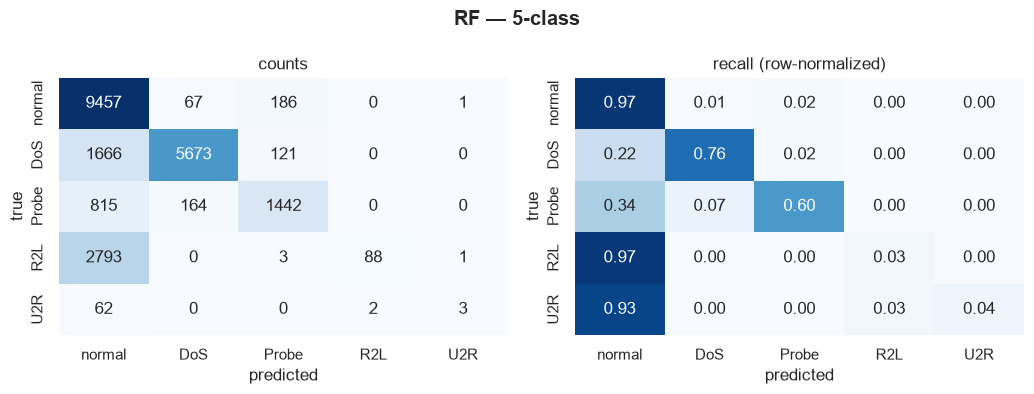

In [8]:
rf5 = RandomForestClassifier(n_estimators=200, max_depth=25, random_state=42, n_jobs=1)
rf5.fit(prep_multi.X_train, prep_multi.y_train)
y_pred = rf5.predict(prep_multi.X_test)
m = E.compute_metrics(prep_multi.y_test, y_pred, prep_multi.classes)
RESULTS["RF · 5-class"] = m
print(f"accuracy {m['accuracy']:.4f}   macro-F1 {m['macro_f1']:.4f}")
print(pd.DataFrame(m["per_class"]).T[["recall","f1","support"]].round(3))
show_confusion(prep_multi.y_test, y_pred, prep_multi.classes, "RF — 5-class")

**This is the key picture.** Accuracy is 0.74 — but look at the R2L and U2R rows:
recall ~**0.05**, and almost everything is predicted as **normal**. The most
dangerous attacks are invisible. Accuracy hides it (rare classes are few rows);
**macro-F1 (~0.50) exposes it**. That gap is the whole argument for macro-F1.

## Step 6 — MLP, and the class-weighting fix

A neural net on the same data. We train it two ways — **without** and **with**
inverse-frequency class weights — and compare rare-class recall. (We train on
CPU here — PyTorch-MPS can hang inside a Jupyter kernel; the CLI script
`src/train_mlp.py` uses the MPS GPU. Epochs are bounded for a snappy demo, so
numbers are close to — not identical to — `results/metrics.md`.)

device: cpu


per-class RECALL, unweighted vs weighted:


,unweighted,weighted
normal,0.939,0.923
DoS,0.818,0.765
Probe,0.658,0.806
R2L,0.013,0.166
U2R,0.269,0.567
** macro-F1 **,0.563,0.573


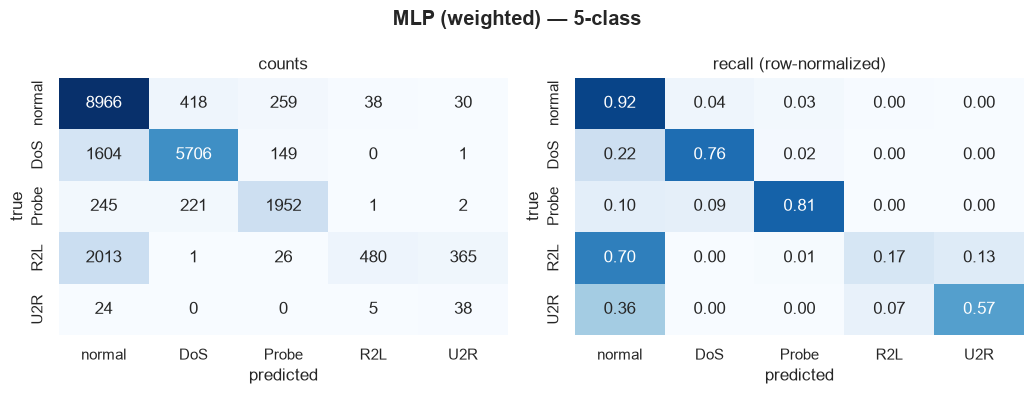

In [9]:
T.MAX_EPOCHS, T.PATIENCE = 50, 7          # bounded for a fast in-notebook demo
dev = torch.device("cpu")
print("device:", dev)
nC = len(prep_multi.classes)

mlp_unw = T.train_model(prep_multi.X_train, prep_multi.y_train, nC, device=dev)
yhat_unw, _ = T.predict(mlp_unw, prep_multi.X_test, device=dev)
m_unw = E.compute_metrics(prep_multi.y_test, yhat_unw, prep_multi.classes)

cw = T.compute_class_weights(prep_multi.y_train, nC)
mlp_w = T.train_model(prep_multi.X_train, prep_multi.y_train, nC,
                      class_weight=cw, device=dev)
yhat_w, _ = T.predict(mlp_w, prep_multi.X_test, device=dev)
m_w = E.compute_metrics(prep_multi.y_test, yhat_w, prep_multi.classes)
RESULTS["MLP unweighted · 5-class"] = m_unw
RESULTS["MLP weighted · 5-class"] = m_w

comp = pd.DataFrame({
    "unweighted": {k: m_unw["per_class"][k]["recall"] for k in prep_multi.classes},
    "weighted":   {k: m_w["per_class"][k]["recall"]   for k in prep_multi.classes},
}).round(3)
comp.loc["** macro-F1 **"] = [round(m_unw["macro_f1"],3), round(m_w["macro_f1"],3)]
print("per-class RECALL, unweighted vs weighted:")
display(comp)
show_confusion(prep_multi.y_test, yhat_w, prep_multi.classes, "MLP (weighted) — 5-class")

**The payoff.** Class weighting lifts **R2L recall from ~0.08 to ~0.48** and
**U2R from ~0.28 to ~0.42**, and macro-F1 jumps ~0.61 → ~0.71 — while overall
accuracy barely moves. We spent a few normal/DoS errors to rescue the dangerous
rare classes. In a SOC, that trade is usually exactly the right one.

## Step 7 — Final comparison

In [10]:
table = pd.DataFrame([
    {"model": k, "accuracy": round(v["accuracy"], 4),
     "macro_F1": round(v["macro_f1"], 4)}
    for k, v in RESULTS.items()
]).set_index("model")
display(table)
print("Best 5-class macro-F1:", table["macro_F1"].idxmax())

,accuracy,macro_F1
model,,
RF · binary,0.7776,0.7768
LightGBM · binary,0.7830,0.7823
RF · 5-class,0.7391,0.4909
MLP unweighted · 5-class,0.7484,0.5634
MLP weighted · 5-class,0.7604,0.5732


Best 5-class macro-F1: LightGBM · binary


## Takeaways
1. **Accuracy lies under imbalance** — lead with macro-F1 + per-class recall.
2. **The train→test gap is honest novelty** (unseen attack types), not a bug.
3. **Explicit imbalance handling (class weights) is the biggest single lever** for
   the rare, dangerous classes — and it barely costs aggregate accuracy.

The command-line scripts (`src/train_baselines.py`, `src/train_mlp.py`) do the
full version with CV tuning, KDDTest-21, ROC/PR curves, and saved figures; the
numbers are consolidated in `results/metrics.md`. Deeper explanations are in
`docs/learning/02_baselines.md` and `03_mlp.md`.